In [1]:
"""
Threshold vs. Ion Count Rate (Exploratory — not used in the final thesis)
=============================================================================
Detector bias held at -2300 V; MPANT threshold varied from -4 mV to -8 mV.

This scan tests how detector count rate depends on discriminator threshold,
background-subtracted against a matched TDC-noise measurement at each
threshold. Not cited as a numbered figure or table in the dissertation --
kept here for completeness/transparency of the analysis history.
"""

import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt

In [2]:
def read_mpa_file(filepath):
    """Parses REALTIME and TOTALSUM from an MPANT ASCII export."""
    realtime = None
    totalsum = None

    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line.startswith("REALTIME") and realtime is None:
                realtime = float(line.split()[1].strip())
            elif line.startswith("TOTALSUM") and totalsum is None:
                totalsum = float(line.split()[1].strip())

    return realtime, totalsum


def get_thres(filename, prefix):
    name_only = filename.replace(prefix, "").replace(".mpa", "")
    name_only = name_only.split("_")[0]
    return int(name_only)


def get_run(filename, prefix):
    name_only = filename.replace(prefix, "").replace(".mpa", "")
    if "_" in name_only:
        return int(name_only.split("_")[1])
    return 1


def build_df(data_folder, glob_pattern, prefix, exclude=None):
    rows = []
    for filepath in glob.glob(os.path.join(data_folder, glob_pattern)):
        filename = os.path.basename(filepath)
        if exclude and exclude in filename:
            continue  # skip files that belong to the other set

        threshold = get_thres(filename, prefix)
        run = get_run(filename, prefix)
        realtime, totalsum = read_mpa_file(filepath)
        rate = totalsum / realtime

        rows.append({
            "threshold": threshold,
            "run": run,
            "file": filename,
            "realtime_s": realtime,
            "totalsum": totalsum,
            "rate_hz": rate
        })
    return pd.DataFrame(rows)


data_folder = "ThresholdControl"

noise_df = build_df(data_folder, "TDCNoise*.mpa", prefix="TDCNoise")
tdc_df = build_df(data_folder, "TDC*.mpa", prefix="TDC", exclude="Noise")

In [3]:
# Aggregate repeated noise measurements at each threshold into one noise rate
noise_summary = (
    noise_df.groupby("threshold")
    .agg(total_counts=("totalsum", "sum"), total_time=("realtime_s", "sum"))
    .reset_index()
)

noise_summary["noise_rate_hz"] = noise_summary["total_counts"] / noise_summary["total_time"]
noise_summary["noise_rate_err_hz"] = np.sqrt(noise_summary["total_counts"]) / noise_summary["total_time"]

threshold_scan = pd.merge(tdc_df, noise_summary[["threshold", "noise_rate_hz", "noise_rate_err_hz"]], on="threshold")

threshold_scan["rate_err_hz"] = np.sqrt(threshold_scan["totalsum"]) / threshold_scan["realtime_s"]
threshold_scan["rate_corrected_hz"] = threshold_scan["rate_hz"] - threshold_scan["noise_rate_hz"]
threshold_scan["rate_corrected_err_hz"] = np.sqrt(
    threshold_scan["rate_err_hz"]**2 + threshold_scan["noise_rate_err_hz"]**2
)

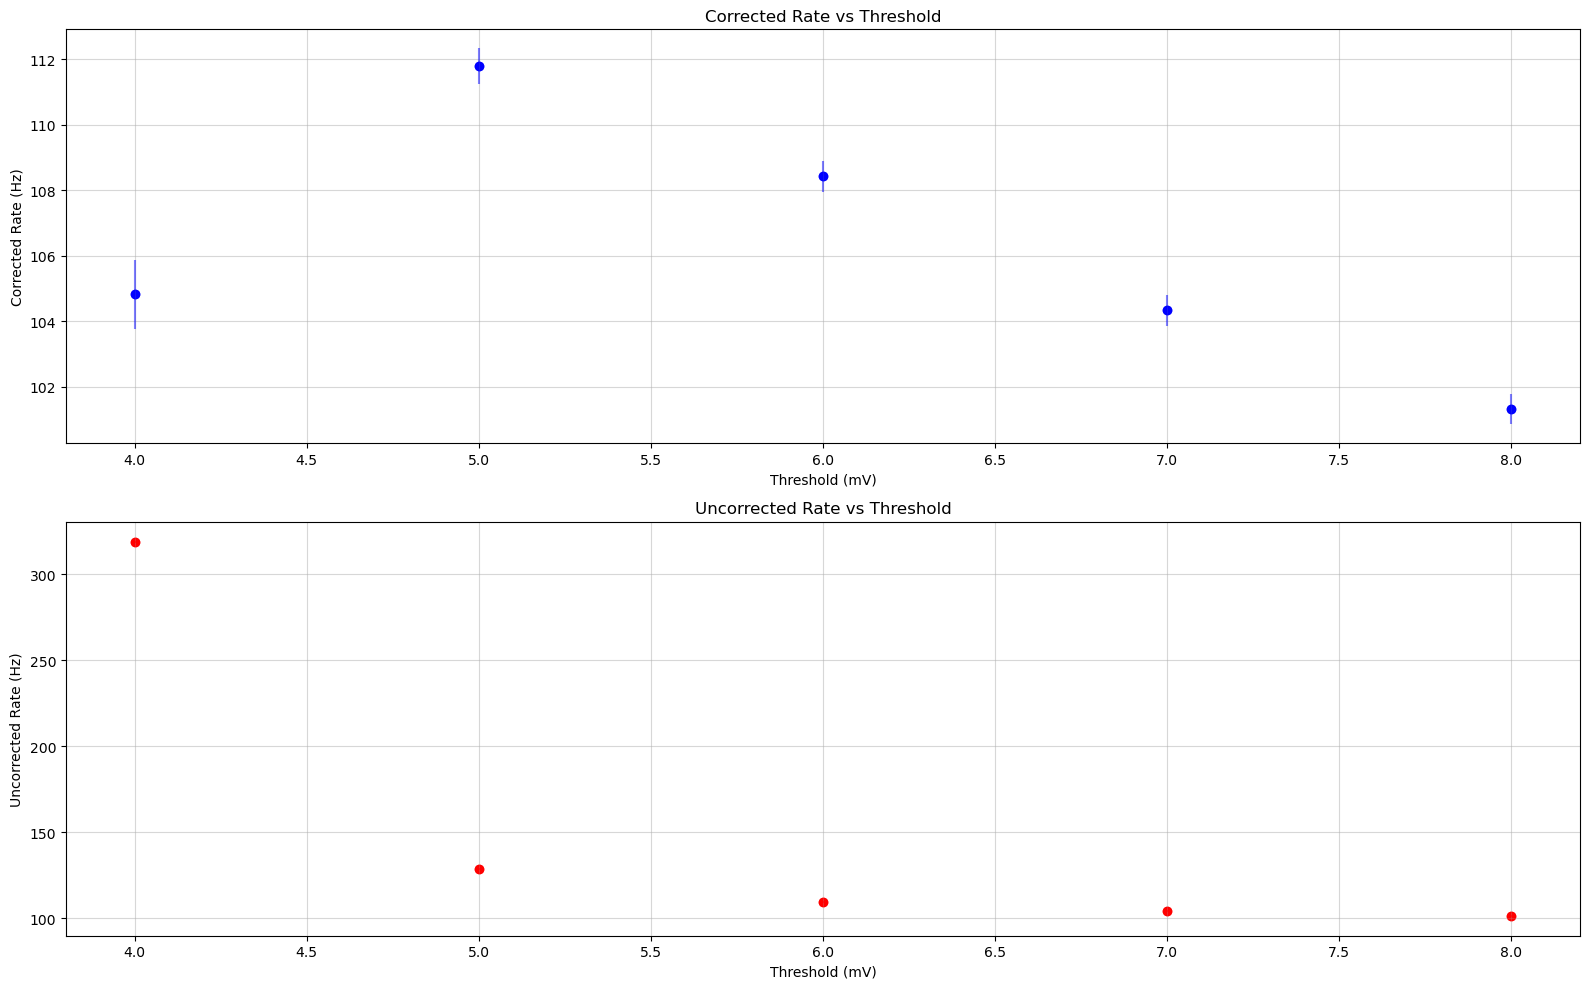

In [4]:
plt.figure(figsize=(16, 10))

plt.subplot(2, 1, 1)
plt.scatter(threshold_scan["threshold"], threshold_scan["rate_corrected_hz"], color="blue")
plt.errorbar(threshold_scan["threshold"], threshold_scan["rate_corrected_hz"],
             yerr=threshold_scan["rate_corrected_err_hz"], fmt='o', color="blue", alpha=0.5)
plt.xlabel("Threshold (mV)")
plt.ylabel("Corrected Rate (Hz)")
plt.title("Corrected Rate vs Threshold")
plt.grid(alpha=0.5)

plt.subplot(2, 1, 2)
plt.scatter(threshold_scan["threshold"], threshold_scan["rate_hz"], color="red")
plt.errorbar(threshold_scan["threshold"], threshold_scan["rate_hz"],
             yerr=threshold_scan["rate_err_hz"], fmt='o', color="red", alpha=0.5)
plt.xlabel("Threshold (mV)")
plt.ylabel("Uncorrected Rate (Hz)")
plt.title("Uncorrected Rate vs Threshold")
plt.grid(alpha=0.5)

plt.tight_layout()
plt.show()